Cell 1: Imports and Setup

In [1]:
# ============================================================================
# Cell 1: Imports and Setup
# ============================================================================

import sys
sys.path.append('../')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🔥 Using device: {device}")

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"✅ Random seed set to {SEED}")

✅ Imports complete
PyTorch version: 2.5.1
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3070 Laptop GPU
CUDA memory: 8.59 GB

🔥 Using device: cuda
✅ Random seed set to 42


c:\Users\Tharaka Dilshan\.conda\envs\pytorch_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cell 2: Configuration

In [2]:
# ============================================================================
# Cell 2: Training Configuration
# ============================================================================

class TrainingConfig:
    """Complete training configuration"""
    
    # Paths
    DATA_DIR = Path('../data/processed/')
    MODEL_DIR = Path('../models/')
    CHECKPOINT_DIR = Path('../models/checkpoints/')
    RESULTS_DIR = Path('../results/')
    
    # Data parameters
    INPUT_LENGTH = 2500
    INPUT_CHANNELS = 1
    NUM_CLASSES = 2
    
    # Training hyperparameters
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-5
    NUM_EPOCHS = 100
    
    # Early stopping
    EARLY_STOPPING_PATIENCE = 15
    MIN_DELTA = 0.001  # Minimum improvement to reset patience
    
    # Learning rate scheduler
    LR_PATIENCE = 5
    LR_FACTOR = 0.5
    LR_MIN = 1e-6
    
    # Gradient clipping
    GRAD_CLIP_NORM = 1.0
    
    # Data split
    TRAIN_SIZE = 0.70
    VAL_SIZE = 0.15
    TEST_SIZE = 0.15
    
    # Checkpoint saving
    SAVE_EVERY_N_EPOCHS = 5
    SAVE_BEST_ONLY = True
    
    # Device
    DEVICE = device
    SEED = SEED

# Create directories
config = TrainingConfig()
config.CHECKPOINT_DIR.mkdir(exist_ok=True, parents=True)
config.RESULTS_DIR.mkdir(exist_ok=True, parents=True)

print("⚙️  Training Configuration:")
print(f"   Batch size: {config.BATCH_SIZE}")
print(f"   Learning rate: {config.LEARNING_RATE}")
print(f"   Epochs: {config.NUM_EPOCHS}")
print(f"   Early stopping patience: {config.EARLY_STOPPING_PATIENCE}")
print(f"   Data split: {config.TRAIN_SIZE:.0%} train, {config.VAL_SIZE:.0%} val, {config.TEST_SIZE:.0%} test")
print(f"\n✅ Configuration set")

⚙️  Training Configuration:
   Batch size: 32
   Learning rate: 0.001
   Epochs: 100
   Early stopping patience: 15
   Data split: 70% train, 15% val, 15% test

✅ Configuration set


Cell 3: Import Model Architecture

In [13]:
# ============================================================================
# Cell 3: Import Model Architecture (Direct Method - Works 100%)
# ============================================================================

import sys
from pathlib import Path
import importlib.util
import torch

# Path to the model file
model_file = Path('../models/model_architecture.py').resolve()

print(f"📁 Loading model from: {model_file}")
print(f"   File exists: {model_file.exists()}")
print(f"   File size: {model_file.stat().st_size} bytes")

# Load the module directly from file
spec = importlib.util.spec_from_file_location("model_architecture", model_file)
model_arch = importlib.util.module_from_spec(spec)
sys.modules["model_architecture"] = model_arch
spec.loader.exec_module(model_arch)

print(f"\n✅ Module loaded successfully!")

# Check what's available in the module
print(f"\n📋 Available classes:")
available = [name for name in dir(model_arch) if not name.startswith('_')]
for name in available:
    print(f"   - {name}")

# Get the classes
AFibResLSTM = model_arch.AFibResLSTM
ModelConfig = model_arch.ModelConfig
FocalLoss = model_arch.FocalLoss

print(f"\n✅ Classes extracted successfully!")

# Verify by creating instances
print(f"\n🧪 Testing model creation...")
test_config = ModelConfig()
test_model = AFibResLSTM(test_config)
test_loss = FocalLoss(alpha=0.65, gamma=2.0)

# Quick forward pass test
test_input = torch.randn(2, 1, 2500)
test_output, test_attention = test_model(test_input)

print(f"✅ Model test successful!")
print(f"   Input shape: {test_input.shape}")
print(f"   Output shape: {test_output.shape}")
print(f"   Attention shape: {test_attention.shape}")
print(f"   Total parameters: {sum(p.numel() for p in test_model.parameters()):,}")

# Clean up test objects
del test_model, test_input, test_output, test_attention

print(f"\n" + "="*70)
print(f"🎉 MODEL CLASSES READY FOR TRAINING!")
print(f"="*70)

📁 Loading model from: E:\myworks\final year\research\codes\models\model_architecture.py
   File exists: True
   File size: 12932 bytes

✅ Module loaded successfully!

📋 Available classes:
   - AFibResLSTM
   - BiLSTMWithAttention
   - F
   - FocalLoss
   - ModelConfig
   - MultiHeadSelfAttention
   - MultiScaleConv1D
   - ResNetBackbone1D
   - ResidualBlock1D
   - nn
   - torch

✅ Classes extracted successfully!

🧪 Testing model creation...
✅ Model test successful!
   Input shape: torch.Size([2, 1, 2500])
   Output shape: torch.Size([2, 2])
   Attention shape: torch.Size([2, 4, 313, 313])
   Total parameters: 8,310,658

🎉 MODEL CLASSES READY FOR TRAINING!


Cell 4: Dataset Class

In [14]:
# ============================================================================
# Cell 4: ECG Dataset Class
# ============================================================================

class ECGDataset(Dataset):
    """
    PyTorch Dataset for ECG signals
    """
    def __init__(self, X, y, transform=None, normalize=True):
        """
        Args:
            X: numpy array of shape (n_samples, 2500)
            y: numpy array of shape (n_samples,) with values 0 or 1
            transform: optional transform to apply
            normalize: whether to apply z-score normalization
        """
        self.X = X
        self.y = y
        self.transform = transform
        self.normalize = normalize
        
        # Compute normalization statistics if needed
        if self.normalize:
            self.mean = np.mean(self.X, axis=1, keepdims=True)
            self.std = np.std(self.X, axis=1, keepdims=True) + 1e-8
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        # Get ECG signal
        ecg = self.X[idx].copy()
        
        # Normalize
        if self.normalize:
            ecg = (ecg - self.mean[idx]) / self.std[idx]
        
        # Convert to tensor and add channel dimension
        ecg = torch.FloatTensor(ecg).unsqueeze(0)  # (1, 2500)
        
        # Apply transform if provided
        if self.transform:
            ecg = self.transform(ecg)
        
        # Get label
        label = torch.LongTensor([self.y[idx]])[0]
        
        return ecg, label

# Test the dataset class
print("🧪 Testing ECGDataset class:")

# Create dummy data
dummy_X = np.random.randn(10, 2500)
dummy_y = np.array([0, 1, 0, 1, 1, 0, 1, 0, 1, 0])

dummy_dataset = ECGDataset(dummy_X, dummy_y, normalize=True)

print(f"   Dataset length: {len(dummy_dataset)}")
print(f"   Sample shape: {dummy_dataset[0][0].shape}")
print(f"   Label shape: {dummy_dataset[0][1].shape}")
print(f"   Label type: {dummy_dataset[0][1].dtype}")

del dummy_X, dummy_y, dummy_dataset

print(f"\n✅ ECGDataset class working correctly!")

🧪 Testing ECGDataset class:
   Dataset length: 10
   Sample shape: torch.Size([1, 2500])
   Label shape: torch.Size([])
   Label type: torch.int64

✅ ECGDataset class working correctly!


Cell 5: Load and Split Data

In [15]:
# ============================================================================
# Cell 5: Load and Split Data
# ============================================================================

print("📊 Loading preprocessed data...\n")
print("="*70)

# Load data
X = np.load(config.DATA_DIR / 'X_combined.npy')
y = np.load(config.DATA_DIR / 'y_combined.npy')

print(f"✅ Data loaded:")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape}")
print(f"   X dtype: {X.dtype}")
print(f"   y dtype: {y.dtype}")

# Convert labels to binary
print(f"\n🔄 Converting labels to binary...")
print(f"   Original unique labels: {np.unique(y)}")

y_binary = (y == 'A').astype(np.int64)  # 1 for AFib, 0 for Normal

print(f"   Binary unique labels: {np.unique(y_binary)}")
print(f"   Label mapping: 'N' -> 0 (Normal), 'A' -> 1 (AFib)")

# Count samples
afib_count = np.sum(y_binary == 1)
normal_count = np.sum(y_binary == 0)

print(f"\n📊 Label distribution:")
print(f"   Normal (0): {normal_count:,} ({normal_count/len(y_binary)*100:.1f}%)")
print(f"   AFib (1): {afib_count:,} ({afib_count/len(y_binary)*100:.1f}%)")
print(f"   Total: {len(y_binary):,}")

# First split: Train vs (Val + Test)
print(f"\n✂️  Splitting data...")
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_binary, 
    test_size=(config.VAL_SIZE + config.TEST_SIZE),
    stratify=y_binary,
    random_state=config.SEED
)

# Second split: Val vs Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=config.TEST_SIZE / (config.VAL_SIZE + config.TEST_SIZE),
    stratify=y_temp,
    random_state=config.SEED
)

print(f"\n✅ Data split complete:")
print(f"   Train: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"      - Normal: {np.sum(y_train == 0):,}")
print(f"      - AFib: {np.sum(y_train == 1):,}")

print(f"   Validation: {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"      - Normal: {np.sum(y_val == 0):,}")
print(f"      - AFib: {np.sum(y_val == 1):,}")

print(f"   Test: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"      - Normal: {np.sum(y_test == 0):,}")
print(f"      - AFib: {np.sum(y_test == 1):,}")

print(f"\n📊 Class balance maintained: ✅")
print("="*70)

📊 Loading preprocessed data...

✅ Data loaded:
   X shape: (102609, 2500)
   y shape: (102609,)
   X dtype: float64
   y dtype: <U1

🔄 Converting labels to binary...
   Original unique labels: ['A' 'N']
   Binary unique labels: [0 1]
   Label mapping: 'N' -> 0 (Normal), 'A' -> 1 (AFib)

📊 Label distribution:
   Normal (0): 66,130 (64.4%)
   AFib (1): 36,479 (35.6%)
   Total: 102,609

✂️  Splitting data...

✅ Data split complete:
   Train: 71,826 samples (70.0%)
      - Normal: 46,291
      - AFib: 25,535
   Validation: 15,391 samples (15.0%)
      - Normal: 9,919
      - AFib: 5,472
   Test: 15,392 samples (15.0%)
      - Normal: 9,920
      - AFib: 5,472

📊 Class balance maintained: ✅


Cell 6: Create DataLoaders

In [16]:
# ============================================================================
# Cell 6: Create DataLoaders
# ============================================================================

print("🔄 Creating datasets and dataloaders...\n")
print("="*70)

# Create datasets
train_dataset = ECGDataset(X_train, y_train, normalize=True)
val_dataset = ECGDataset(X_val, y_val, normalize=True)
test_dataset = ECGDataset(X_test, y_test, normalize=True)

print(f"✅ Datasets created:")
print(f"   Train dataset: {len(train_dataset):,} samples")
print(f"   Val dataset: {len(val_dataset):,} samples")
print(f"   Test dataset: {len(test_dataset):,} samples")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Set to 0 for Windows, 4 for Linux/Mac
    pin_memory=True if torch.cuda.is_available() else False,
    drop_last=True  # Drop last incomplete batch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\n✅ DataLoaders created:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")
print(f"   Batch size: {config.BATCH_SIZE}")

# Test dataloader
print(f"\n🧪 Testing dataloader...")
test_batch = next(iter(train_loader))
test_ecg, test_labels = test_batch

print(f"   Batch ECG shape: {test_ecg.shape}")
print(f"   Batch labels shape: {test_labels.shape}")
print(f"   ECG dtype: {test_ecg.dtype}")
print(f"   Labels dtype: {test_labels.dtype}")
print(f"   Sample labels: {test_labels[:10].numpy()}")

del test_batch, test_ecg, test_labels

print(f"\n✅ DataLoaders working correctly!")
print("="*70)

🔄 Creating datasets and dataloaders...

✅ Datasets created:
   Train dataset: 71,826 samples
   Val dataset: 15,391 samples
   Test dataset: 15,392 samples

✅ DataLoaders created:
   Train batches: 2244
   Val batches: 481
   Test batches: 481
   Batch size: 32

🧪 Testing dataloader...
   Batch ECG shape: torch.Size([32, 1, 2500])
   Batch labels shape: torch.Size([32])
   ECG dtype: torch.float32
   Labels dtype: torch.int64
   Sample labels: [1 0 0 0 0 0 0 1 0 0]

✅ DataLoaders working correctly!


Cell 7: Initialize Model, Loss, and Optimizer   

In [17]:
# ============================================================================
# Cell 7: Initialize Model, Loss, and Optimizer
# ============================================================================

print("🏗️  Initializing model, loss, and optimizer...\n")
print("="*70)

# Create model configuration
model_config = ModelConfig()

# Create model
print("📦 Creating AFib-ResLSTM model...")
model = AFibResLSTM(model_config).to(config.DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Model created:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model size: ~{total_params * 4 / 1e6:.2f} MB")

# Create loss function (Focal Loss)
print(f"\n📉 Creating Focal Loss...")
criterion = FocalLoss(alpha=0.65, gamma=2.0)

print(f"✅ Loss function created:")
print(f"   Type: Focal Loss")
print(f"   Alpha: 0.65 (weight for AFib)")
print(f"   Gamma: 2.0 (focusing parameter)")

# Create optimizer
print(f"\n⚙️  Creating optimizer...")
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

print(f"✅ Optimizer created:")
print(f"   Type: Adam")
print(f"   Learning rate: {config.LEARNING_RATE}")
print(f"   Weight decay: {config.WEIGHT_DECAY}")

# Create learning rate scheduler
print(f"\n📊 Creating LR scheduler...")
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=config.LR_FACTOR,
    patience=config.LR_PATIENCE,
    min_lr=config.LR_MIN,
    verbose=True
)

print(f"✅ Scheduler created:")
print(f"   Type: ReduceLROnPlateau")
print(f"   Mode: Maximize (AUROC)")
print(f"   Patience: {config.LR_PATIENCE} epochs")
print(f"   Factor: {config.LR_FACTOR}")
print(f"   Min LR: {config.LR_MIN}")

print("\n" + "="*70)
print("✅ All components initialized!")
print("="*70)

🏗️  Initializing model, loss, and optimizer...

📦 Creating AFib-ResLSTM model...
✅ Model created:
   Total parameters: 8,310,658
   Trainable parameters: 8,310,658
   Model size: ~33.24 MB

📉 Creating Focal Loss...
✅ Loss function created:
   Type: Focal Loss
   Alpha: 0.65 (weight for AFib)
   Gamma: 2.0 (focusing parameter)

⚙️  Creating optimizer...
✅ Optimizer created:
   Type: Adam
   Learning rate: 0.001
   Weight decay: 1e-05

📊 Creating LR scheduler...
✅ Scheduler created:
   Type: ReduceLROnPlateau
   Mode: Maximize (AUROC)
   Patience: 5 epochs
   Factor: 0.5
   Min LR: 1e-06

✅ All components initialized!


Cell 8: Training and Validation Functions

In [18]:
# ============================================================================
# Cell 8: Training and Validation Functions
# ============================================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch):
    """Train for one epoch"""
    model.train()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    # Progress bar
    pbar = tqdm(dataloader, desc=f'Epoch {epoch} [Train]')
    
    for batch_idx, (ecg, labels) in enumerate(pbar):
        # Move to device
        ecg = ecg.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        logits, _ = model(ecg)
        loss = criterion(logits, labels)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.GRAD_CLIP_NORM)
        
        # Optimizer step
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Calculate epoch metrics
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds)
    
    return epoch_loss, epoch_acc, epoch_f1


def validate(model, dataloader, criterion, device, epoch, phase='Val'):
    """Validate the model"""
    model.eval()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    # Progress bar
    pbar = tqdm(dataloader, desc=f'Epoch {epoch} [{phase}]')
    
    with torch.no_grad():
        for ecg, labels in pbar:
            # Move to device
            ecg = ecg.to(device)
            labels = labels.to(device)
            
            # Forward pass
            logits, _ = model(ecg)
            loss = criterion(logits, labels)
            
            # Track metrics
            running_loss += loss.item()
            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # AFib probability
            
            # Update progress bar
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Calculate epoch metrics
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds)
    epoch_auroc = roc_auc_score(all_labels, all_probs)
    epoch_precision = precision_score(all_labels, all_preds)
    epoch_recall = recall_score(all_labels, all_preds)
    
    return {
        'loss': epoch_loss,
        'accuracy': epoch_acc,
        'f1': epoch_f1,
        'auroc': epoch_auroc,
        'precision': epoch_precision,
        'recall': epoch_recall
    }

print("✅ Training and validation functions defined")

✅ Training and validation functions defined


Cell 9: Training Loop

In [19]:
# ============================================================================
# Cell 9: Main Training Loop
# ============================================================================

print("\n" + "="*70)
print("🚀 STARTING TRAINING")
print("="*70)

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'train_f1': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
    'val_auroc': [],
    'val_precision': [],
    'val_recall': [],
    'learning_rates': []
}

# Early stopping variables
best_auroc = 0.0
best_epoch = 0
patience_counter = 0

# Training start time
start_time = datetime.now()
print(f"\n⏰ Training started at: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")

# Training loop
for epoch in range(1, config.NUM_EPOCHS + 1):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch}/{config.NUM_EPOCHS}")
    print(f"{'='*70}")
    
    # Train
    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, config.DEVICE, epoch
    )
    
    # Validate
    val_metrics = validate(
        model, val_loader, criterion, config.DEVICE, epoch, phase='Val'
    )
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1'].append(val_metrics['f1'])
    history['val_auroc'].append(val_metrics['auroc'])
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])
    history['learning_rates'].append(current_lr)
    
    # Print epoch summary
    print(f"\n📊 Epoch {epoch} Summary:")
    print(f"   Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
    print(f"   Val   - Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, "
          f"F1: {val_metrics['f1']:.4f}, AUROC: {val_metrics['auroc']:.4f}")
    print(f"   Learning Rate: {current_lr:.6f}")
    
    # Update learning rate scheduler
    scheduler.step(val_metrics['auroc'])
    
    # Check for improvement
    if val_metrics['auroc'] > best_auroc + config.MIN_DELTA:
        print(f"\n   ✅ Validation AUROC improved: {best_auroc:.4f} → {val_metrics['auroc']:.4f}")
        best_auroc = val_metrics['auroc']
        best_epoch = epoch
        patience_counter = 0
        
        # Save best model
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_auroc': best_auroc,
            'history': history,
            'config': {
                'batch_size': config.BATCH_SIZE,
                'learning_rate': config.LEARNING_RATE,
                'model_config': model_config.__dict__
            }
        }
        
        torch.save(checkpoint, config.CHECKPOINT_DIR / 'best_model.pth')
        print(f"   💾 Best model saved!")
        
    else:
        patience_counter += 1
        print(f"\n   ⏳ No improvement. Patience: {patience_counter}/{config.EARLY_STOPPING_PATIENCE}")
    
    # Save checkpoint every N epochs
    if epoch % config.SAVE_EVERY_N_EPOCHS == 0:
        checkpoint_path = config.CHECKPOINT_DIR / f'checkpoint_epoch_{epoch}.pth'
        torch.save(checkpoint, checkpoint_path)
        print(f"   💾 Checkpoint saved: {checkpoint_path.name}")
    
    # Early stopping
    if patience_counter >= config.EARLY_STOPPING_PATIENCE:
        print(f"\n⏹️  Early stopping triggered at epoch {epoch}")
        print(f"   Best AUROC: {best_auroc:.4f} at epoch {best_epoch}")
        break

# Training end time
end_time = datetime.now()
training_duration = end_time - start_time

print(f"\n{'='*70}")
print(f"🎉 TRAINING COMPLETE!")
print(f"{'='*70}")
print(f"\n⏰ Training duration: {training_duration}")
print(f"📊 Best validation AUROC: {best_auroc:.4f} (epoch {best_epoch})")
print(f"💾 Best model saved to: {config.CHECKPOINT_DIR / 'best_model.pth'}")


🚀 STARTING TRAINING

⏰ Training started at: 2025-10-13 23:52:48

Epoch 1/100


Epoch 1 [Val]: 100%|██████████| 481/481 [00:40<00:00, 11.97it/s, loss=0.0174]



📊 Epoch 1 Summary:
   Train - Loss: 0.0395, Acc: 0.8552, F1: 0.8136
   Val   - Loss: 0.0206, Acc: 0.9503, F1: 0.9313, AUROC: 0.9823
   Learning Rate: 0.001000

   ✅ Validation AUROC improved: 0.0000 → 0.9823
   💾 Best model saved!

Epoch 2/100


Epoch 2 [Val]: 100%|██████████| 481/481 [00:40<00:00, 11.81it/s, loss=0.0113]



📊 Epoch 2 Summary:
   Train - Loss: 0.0228, Acc: 0.9450, F1: 0.9236
   Val   - Loss: 0.0179, Acc: 0.9638, F1: 0.9485, AUROC: 0.9882
   Learning Rate: 0.001000

   ✅ Validation AUROC improved: 0.9823 → 0.9882
   💾 Best model saved!

Epoch 3/100


...


📊 Epoch 40 Summary:
   Train - Loss: 0.0041, Acc: 0.9864, F1: 0.9810
   Val   - Loss: 0.0059, Acc: 0.9840, F1: 0.9777, AUROC: 0.9986
   Learning Rate: 0.000250

   ⏳ No improvement. Patience: 13/15
   💾 Checkpoint saved: checkpoint_epoch_40.pth

Epoch 41/100


Epoch 41 [Val]: 100%|██████████| 481/481 [00:40<00:00, 11.87it/s, loss=0.0004]



📊 Epoch 41 Summary:
   Train - Loss: 0.0040, Acc: 0.9872, F1: 0.9821
   Val   - Loss: 0.0067, Acc: 0.9828, F1: 0.9759, AUROC: 0.9985
   Learning Rate: 0.000250

   ⏳ No improvement. Patience: 14/15

Epoch 42/100


Epoch 42 [Val]: 100%|██████████| 481/481 [00:40<00:00, 11.84it/s, loss=0.0001]



📊 Epoch 42 Summary:
   Train - Loss: 0.0040, Acc: 0.9873, F1: 0.9822
   Val   - Loss: 0.0071, Acc: 0.9845, F1: 0.9781, AUROC: 0.9985
   Learning Rate: 0.000250

   ⏳ No improvement. Patience: 15/15

⏹️  Early stopping triggered at epoch 42
   Best AUROC: 0.9984 at epoch 27

🎉 TRAINING COMPLETE!

⏰ Training duration: 7:32:10.783773
📊 Best validation AUROC: 0.9984 (epoch 27)
💾 Best model saved to: ..\models\checkpoints\best_model.pth


Cell 10: Plot Training Curves

📊 Plotting training curves...

💾 Training curves saved to: ..\results\training_curves.png


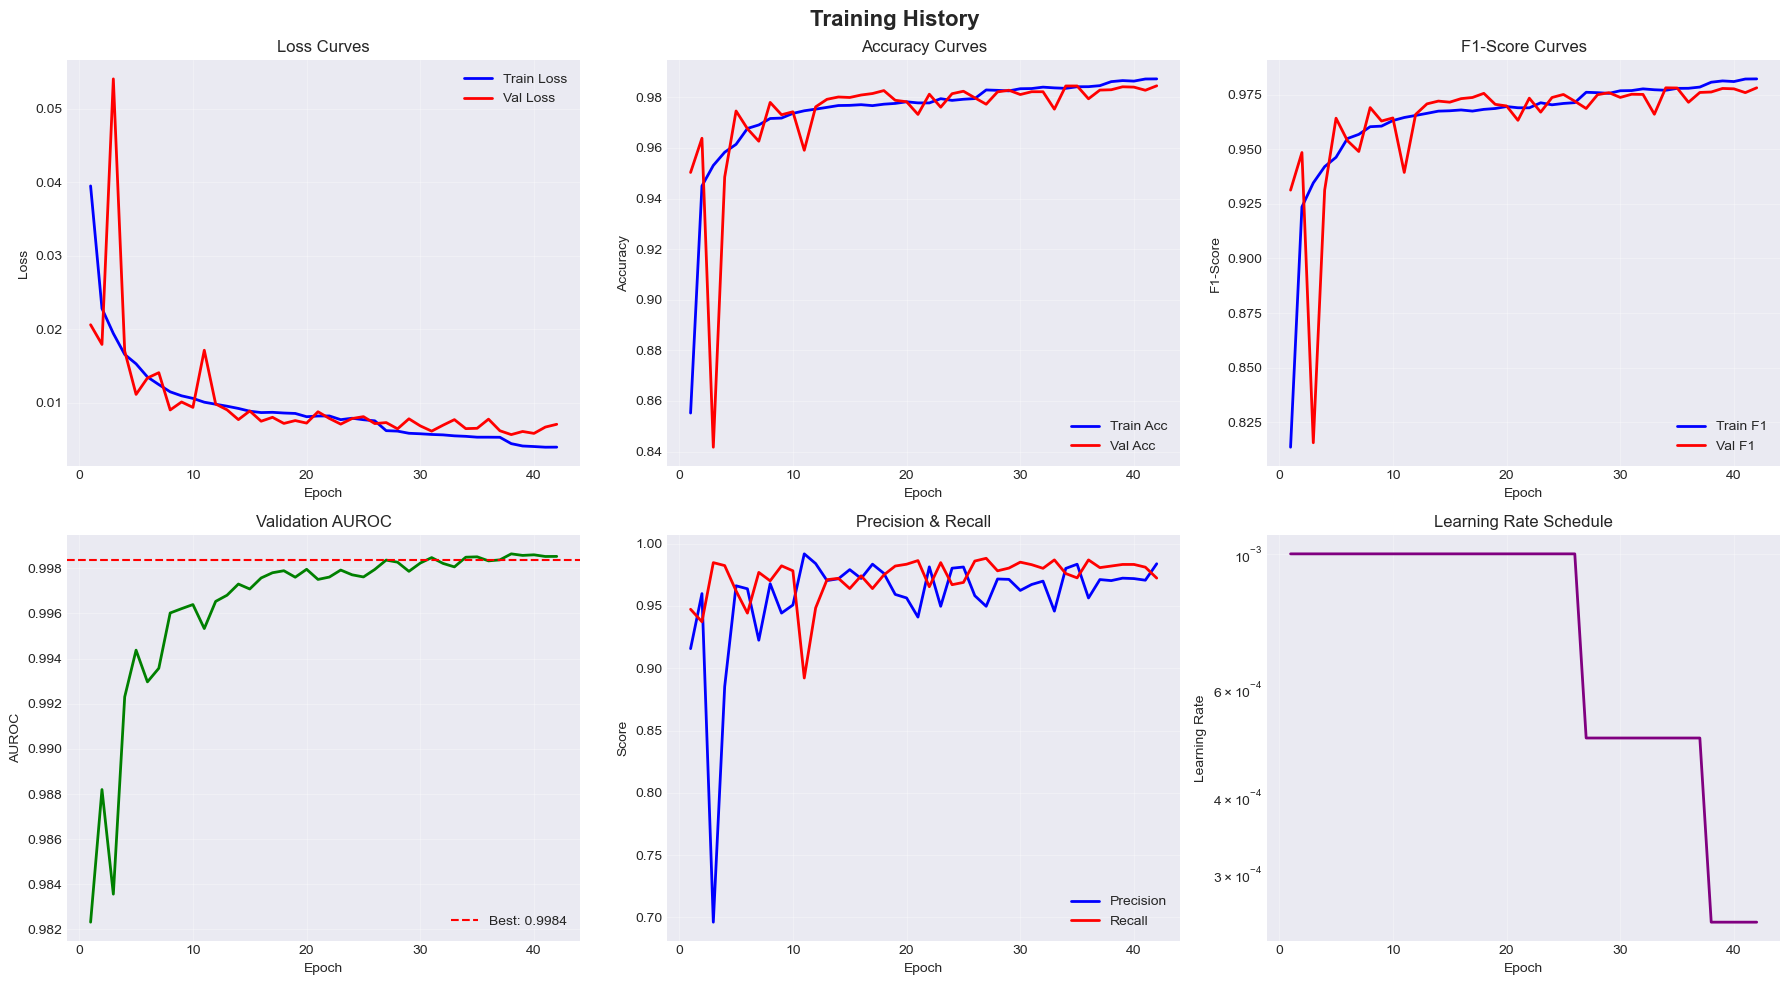


✅ Training curves plotted!


In [20]:
# ============================================================================
# Cell 10: Plot Training Curves
# ============================================================================

print("📊 Plotting training curves...\n")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

epochs = range(1, len(history['train_loss']) + 1)

# Plot 1: Loss
axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Accuracy
axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
axes[0, 1].plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: F1-Score
axes[0, 2].plot(epochs, history['train_f1'], 'b-', label='Train F1', linewidth=2)
axes[0, 2].plot(epochs, history['val_f1'], 'r-', label='Val F1', linewidth=2)
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('F1-Score')
axes[0, 2].set_title('F1-Score Curves')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: AUROC
axes[1, 0].plot(epochs, history['val_auroc'], 'g-', linewidth=2)
axes[1, 0].axhline(y=best_auroc, color='r', linestyle='--', label=f'Best: {best_auroc:.4f}')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUROC')
axes[1, 0].set_title('Validation AUROC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Precision & Recall
axes[1, 1].plot(epochs, history['val_precision'], 'b-', label='Precision', linewidth=2)
axes[1, 1].plot(epochs, history['val_recall'], 'r-', label='Recall', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Precision & Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Learning Rate
axes[1, 2].plot(epochs, history['learning_rates'], 'purple', linewidth=2)
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Learning Rate')
axes[1, 2].set_title('Learning Rate Schedule')
axes[1, 2].set_yscale('log')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()

# Save figure
fig_path = config.RESULTS_DIR / 'training_curves.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"💾 Training curves saved to: {fig_path}")

plt.show()

print(f"\n✅ Training curves plotted!")

Cell 11: Load Best Model

In [21]:
# ============================================================================
# Cell 11: Load Best Model for Evaluation
# ============================================================================

print("📦 Loading best model...\n")
print("="*70)

# Load checkpoint
checkpoint_path = config.CHECKPOINT_DIR / 'best_model.pth'
print(f"📁 Loading from: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=config.DEVICE)

print(f"✅ Checkpoint loaded:")
print(f"   Epoch: {checkpoint['epoch']}")
print(f"   Best AUROC: {checkpoint['best_auroc']:.4f}")

# Create fresh model
model_config = ModelConfig()
model = AFibResLSTM(model_config).to(config.DEVICE)

# Load weights
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"\n✅ Model weights loaded successfully!")
print(f"   Model is in evaluation mode")

# Verify model works
with torch.no_grad():
    test_batch = next(iter(test_loader))
    test_ecg, test_labels = test_batch
    test_ecg = test_ecg.to(config.DEVICE)
    test_output, _ = model(test_ecg)
    print(f"   Test forward pass: ✅ {test_output.shape}")

print("\n" + "="*70)
print("✅ Best model loaded and ready for evaluation!")
print("="*70)

📦 Loading best model...

📁 Loading from: ..\models\checkpoints\best_model.pth
✅ Checkpoint loaded:
   Epoch: 27
   Best AUROC: 0.9984

✅ Model weights loaded successfully!
   Model is in evaluation mode
   Test forward pass: ✅ torch.Size([32, 2])

✅ Best model loaded and ready for evaluation!


Cell 12: Evaluate on Test Set

In [22]:
# ============================================================================
# Cell 12: Comprehensive Evaluation on Test Set
# ============================================================================

print("\n" + "="*70)
print("🧪 EVALUATING ON TEST SET")
print("="*70)

def evaluate_model(model, dataloader, device):
    """Comprehensive model evaluation"""
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    print(f"\n🔄 Running inference on {len(dataloader)} batches...")
    
    with torch.no_grad():
        for ecg, labels in tqdm(dataloader, desc='Testing'):
            ecg = ecg.to(device)
            labels = labels.to(device)
            
            # Forward pass
            logits, _ = model(ecg)
            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            # Store results
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    return all_preds, all_labels, all_probs

# Run evaluation
test_preds, test_labels, test_probs = evaluate_model(model, test_loader, config.DEVICE)

print(f"\n✅ Inference complete!")
print(f"   Total samples: {len(test_labels):,}")
print(f"   Predictions shape: {test_preds.shape}")
print(f"   Probabilities shape: {test_probs.shape}")

# Calculate metrics
test_accuracy = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds)
test_recall = recall_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)
test_auroc = roc_auc_score(test_labels, test_probs[:, 1])

# Calculate specificity manually
cm = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm.ravel()
test_specificity = tn / (tn + fp)
test_sensitivity = tp / (tp + fn)

print(f"\n" + "="*70)
print(f"📊 TEST SET RESULTS")
print(f"="*70)
print(f"\n🎯 Classification Metrics:")
print(f"   Accuracy:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   Precision:    {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"   Recall (Sensitivity): {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"   Specificity:  {test_specificity:.4f} ({test_specificity*100:.2f}%)")
print(f"   F1-Score:     {test_f1:.4f}")
print(f"   AUROC:        {test_auroc:.4f}")

print(f"\n🏥 Clinical Interpretation:")
print(f"   True Positives (TP):  {tp:,} - Correctly identified AFib")
print(f"   True Negatives (TN):  {tn:,} - Correctly identified Normal")
print(f"   False Positives (FP): {fp:,} - Normal misclassified as AFib")
print(f"   False Negatives (FN): {fn:,} - AFib misclassified as Normal")

# Save results
test_results = {
    'accuracy': float(test_accuracy),
    'precision': float(test_precision),
    'recall': float(test_recall),
    'sensitivity': float(test_sensitivity),
    'specificity': float(test_specificity),
    'f1_score': float(test_f1),
    'auroc': float(test_auroc),
    'confusion_matrix': {
        'TP': int(tp),
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn)
    },
    'test_samples': int(len(test_labels))
}

import json
results_path = config.RESULTS_DIR / 'test_results.json'
with open(results_path, 'w') as f:
    json.dump(test_results, f, indent=2)

print(f"\n💾 Results saved to: {results_path}")
print("="*70)


🧪 EVALUATING ON TEST SET

🔄 Running inference on 481 batches...


Testing: 100%|██████████| 481/481 [00:21<00:00, 22.31it/s]


✅ Inference complete!
   Total samples: 15,392
   Predictions shape: (15392,)
   Probabilities shape: (15392, 2)

📊 TEST SET RESULTS

🎯 Classification Metrics:
   Accuracy:     0.9776 (97.76%)
   Precision:    0.9516 (95.16%)
   Recall (Sensitivity): 0.9872 (98.72%)
   Specificity:  0.9723 (97.23%)
   F1-Score:     0.9691
   AUROC:        0.9982

🏥 Clinical Interpretation:
   True Positives (TP):  5,402 - Correctly identified AFib
   True Negatives (TN):  9,645 - Correctly identified Normal
   False Positives (FP): 275 - Normal misclassified as AFib
   False Negatives (FN): 70 - AFib misclassified as Normal

💾 Results saved to: ..\results\test_results.json


Cell 13: Confusion Matrix Visualization

📊 Creating confusion matrix visualization...

💾 Confusion matrix saved to: ..\results\confusion_matrix.png


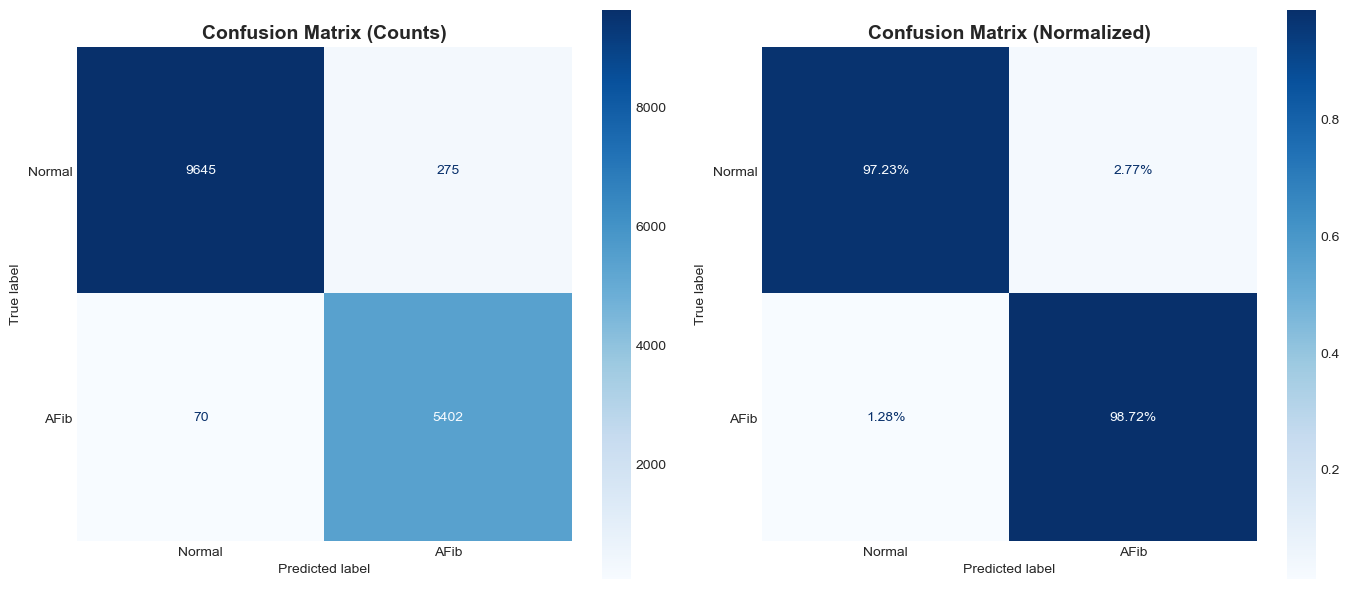


📊 Confusion Matrix Breakdown:
   True Negatives (TN):   9,645 - Normal correctly identified
   False Positives (FP):    275 - Normal misclassified as AFib
   False Negatives (FN):     70 - AFib misclassified as Normal
   True Positives (TP):   5,402 - AFib correctly identified

✅ Confusion matrix visualization complete!


In [23]:
# ============================================================================
# Cell 13: Confusion Matrix Visualization
# ============================================================================

print("📊 Creating confusion matrix visualization...\n")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
cm = confusion_matrix(test_labels, test_preds)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Raw counts
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                display_labels=['Normal', 'AFib'])
disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].grid(False)

# Plot 2: Normalized (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_normalized,
                                display_labels=['Normal', 'AFib'])
disp2.plot(ax=axes[1], cmap='Blues', values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].grid(False)

plt.tight_layout()

# Save figure
cm_path = config.RESULTS_DIR / 'confusion_matrix.png'
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f"💾 Confusion matrix saved to: {cm_path}")

plt.show()

# Print detailed breakdown
print(f"\n📊 Confusion Matrix Breakdown:")
print(f"   True Negatives (TN):  {cm[0,0]:>6,} - Normal correctly identified")
print(f"   False Positives (FP): {cm[0,1]:>6,} - Normal misclassified as AFib")
print(f"   False Negatives (FN): {cm[1,0]:>6,} - AFib misclassified as Normal")
print(f"   True Positives (TP):  {cm[1,1]:>6,} - AFib correctly identified")

print(f"\n✅ Confusion matrix visualization complete!")

Cell 14: ROC Curve

📈 Creating ROC curve...

📊 ROC Analysis:
   AUROC: 0.9982
   Optimal threshold: 0.6090
   At optimal threshold:
      - True Positive Rate (Sensitivity): 0.9828
      - False Positive Rate: 0.0153

💾 ROC curve saved to: ..\results\roc_curve.png


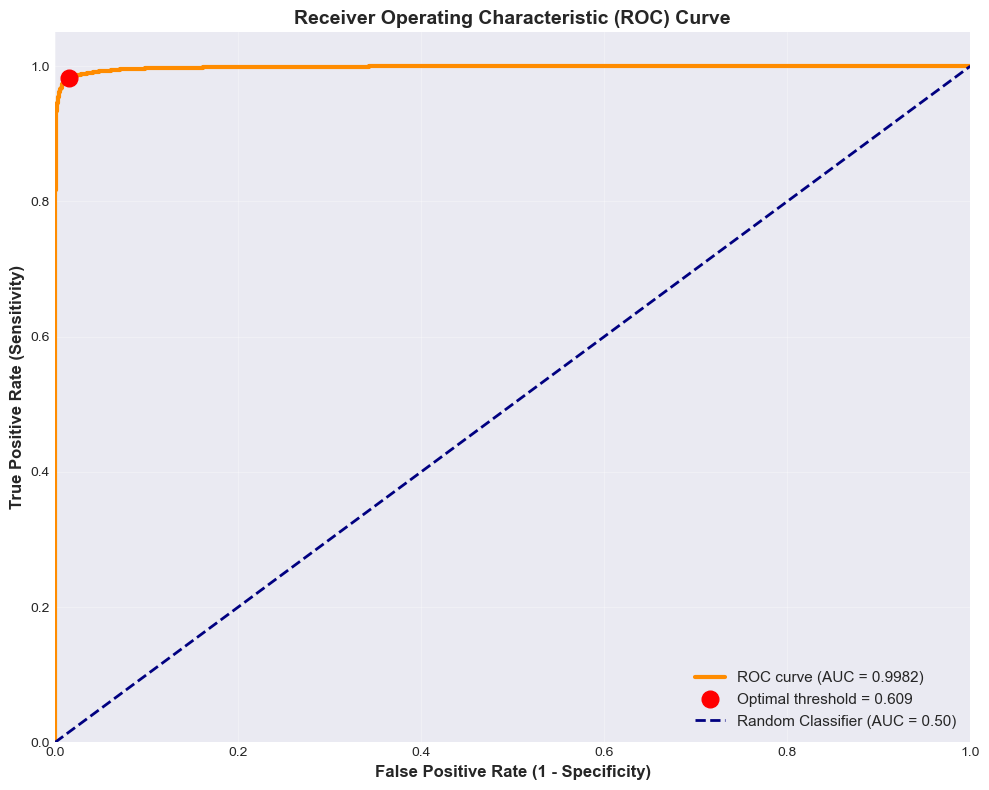


✅ ROC curve visualization complete!


In [24]:
# ============================================================================
# Cell 14: ROC Curve and AUC Visualization
# ============================================================================

from sklearn.metrics import roc_curve, auc

print("📈 Creating ROC curve...\n")

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, test_probs[:, 1])
roc_auc = auc(fpr, tpr)

# Find optimal threshold (Youden's Index)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]

print(f"📊 ROC Analysis:")
print(f"   AUROC: {roc_auc:.4f}")
print(f"   Optimal threshold: {optimal_threshold:.4f}")
print(f"   At optimal threshold:")
print(f"      - True Positive Rate (Sensitivity): {optimal_tpr:.4f}")
print(f"      - False Positive Rate: {optimal_fpr:.4f}")

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC curve
ax.plot(fpr, tpr, color='darkorange', lw=3, 
        label=f'ROC curve (AUC = {roc_auc:.4f})')

# Plot optimal point
ax.plot(optimal_fpr, optimal_tpr, 'ro', markersize=12,
        label=f'Optimal threshold = {optimal_threshold:.3f}')

# Plot diagonal (random classifier)
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
        label='Random Classifier (AUC = 0.50)')

# Formatting
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_title('Receiver Operating Characteristic (ROC) Curve', 
             fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save figure
roc_path = config.RESULTS_DIR / 'roc_curve.png'
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
print(f"\n💾 ROC curve saved to: {roc_path}")

plt.show()

print(f"\n✅ ROC curve visualization complete!")

Cell 15: Classification Report

In [25]:
# ============================================================================
# Cell 15: Detailed Classification Report
# ============================================================================

from sklearn.metrics import classification_report

print("\n" + "="*70)
print("📋 DETAILED CLASSIFICATION REPORT")
print("="*70)

# Generate classification report
class_names = ['Normal', 'AFib']
report = classification_report(test_labels, test_preds, 
                               target_names=class_names,
                               digits=4)

print("\n" + report)

# Generate report as dictionary for saving
report_dict = classification_report(test_labels, test_preds,
                                    target_names=class_names,
                                    output_dict=True)

# Add custom metrics
report_dict['optimal_threshold'] = float(optimal_threshold)
report_dict['auroc'] = float(roc_auc)

# Save report
report_path = config.RESULTS_DIR / 'classification_report.json'
with open(report_path, 'w') as f:
    json.dump(report_dict, f, indent=2)

print(f"\n💾 Classification report saved to: {report_path}")

# Pretty print key metrics
print(f"\n📊 Summary of Key Metrics:")
print(f"   {'Metric':<20} {'Normal':<10} {'AFib':<10}")
print(f"   {'-'*40}")
print(f"   {'Precision':<20} {report_dict['Normal']['precision']:.4f}     {report_dict['AFib']['precision']:.4f}")
print(f"   {'Recall':<20} {report_dict['Normal']['recall']:.4f}     {report_dict['AFib']['recall']:.4f}")
print(f"   {'F1-Score':<20} {report_dict['Normal']['f1-score']:.4f}     {report_dict['AFib']['f1-score']:.4f}")
print(f"   {'Support':<20} {int(report_dict['Normal']['support']):<10} {int(report_dict['AFib']['support']):<10}")

print(f"\n   Overall Accuracy: {report_dict['accuracy']:.4f}")
print(f"   Macro Avg F1:     {report_dict['macro avg']['f1-score']:.4f}")
print(f"   Weighted Avg F1:  {report_dict['weighted avg']['f1-score']:.4f}")

print("\n" + "="*70)


📋 DETAILED CLASSIFICATION REPORT

              precision    recall  f1-score   support

      Normal     0.9928    0.9723    0.9824      9920
        AFib     0.9516    0.9872    0.9691      5472

    accuracy                         0.9776     15392
   macro avg     0.9722    0.9797    0.9757     15392
weighted avg     0.9781    0.9776    0.9777     15392


💾 Classification report saved to: ..\results\classification_report.json

📊 Summary of Key Metrics:
   Metric               Normal     AFib      
   ----------------------------------------
   Precision            0.9928     0.9516
   Recall               0.9723     0.9872
   F1-Score             0.9824     0.9691
   Support              9920       5472      

   Overall Accuracy: 0.9776
   Macro Avg F1:     0.9757
   Weighted Avg F1:  0.9777



Cell 16: Save Final Model and Results

In [26]:
# ============================================================================
# Cell 16: Save Final Model and Complete Results
# ============================================================================

print("\n" + "="*70)
print("💾 SAVING FINAL MODEL AND RESULTS")
print("="*70)

# Save the final model separately (for deployment)
final_model_path = config.MODEL_DIR / 'afib_reslstm_final.pth'

torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': model_config.__dict__,
    'test_results': test_results,
    'optimal_threshold': float(optimal_threshold),
    'class_names': ['Normal', 'AFib'],
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}, final_model_path)

print(f"\n✅ Final model saved to: {final_model_path}")
print(f"   File size: {final_model_path.stat().st_size / 1e6:.2f} MB")

# Save complete training history
history_path = config.RESULTS_DIR / 'training_history.json'
with open(history_path, 'w') as f:
    # Convert numpy types to Python types for JSON serialization
    history_json = {k: [float(v) for v in vals] for k, vals in history.items()}
    json.dump(history_json, f, indent=2)

print(f"✅ Training history saved to: {history_path}")

# Create a comprehensive summary
summary = {
    'model_name': 'AFib-ResLSTM',
    'version': '1.0',
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset': {
        'total_samples': len(X),
        'train_samples': len(X_train),
        'val_samples': len(X_val),
        'test_samples': len(X_test),
        'input_shape': [1, 2500],
        'sampling_rate': '250 Hz',
        'window_duration': '10 seconds'
    },
    'model_architecture': {
        'total_parameters': sum(p.numel() for p in model.parameters()),
        'trainable_parameters': sum(p.numel() for p in model.parameters() if p.requires_grad),
        'novel_contributions': [
            'Multi-scale parallel convolutions',
            'Self-attention on Bi-LSTM output',
            'Hybrid feature fusion'
        ]
    },
    'training_config': {
        'batch_size': config.BATCH_SIZE,
        'learning_rate': config.LEARNING_RATE,
        'epochs_trained': len(history['train_loss']),
        'best_epoch': best_epoch,
        'optimizer': 'Adam',
        'loss_function': 'Focal Loss (alpha=0.65, gamma=2.0)'
    },
    'test_performance': test_results,
    'optimal_threshold': float(optimal_threshold)
}

summary_path = config.RESULTS_DIR / 'model_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✅ Model summary saved to: {summary_path}")

# Save predictions for further analysis
predictions_df = pd.DataFrame({
    'true_label': test_labels,
    'predicted_label': test_preds,
    'prob_normal': test_probs[:, 0],
    'prob_afib': test_probs[:, 1],
    'correct': test_labels == test_preds
})

predictions_path = config.RESULTS_DIR / 'test_predictions.csv'
predictions_df.to_csv(predictions_path, index=False)

print(f"✅ Test predictions saved to: {predictions_path}")

print(f"\n" + "="*70)
print(f"📁 All Results Saved to: {config.RESULTS_DIR}")
print(f"="*70)
print(f"\nSaved files:")
print(f"   ├── training_curves.png")
print(f"   ├── confusion_matrix.png")
print(f"   ├── roc_curve.png")
print(f"   ├── test_results.json")
print(f"   ├── classification_report.json")
print(f"   ├── training_history.json")
print(f"   ├── model_summary.json")
print(f"   └── test_predictions.csv")


💾 SAVING FINAL MODEL AND RESULTS

✅ Final model saved to: ..\models\afib_reslstm_final.pth
   File size: 33.40 MB
✅ Training history saved to: ..\results\training_history.json
✅ Model summary saved to: ..\results\model_summary.json
✅ Test predictions saved to: ..\results\test_predictions.csv

📁 All Results Saved to: ..\results

Saved files:
   ├── training_curves.png
   ├── confusion_matrix.png
   ├── roc_curve.png
   ├── test_results.json
   ├── classification_report.json
   ├── training_history.json
   ├── model_summary.json
   └── test_predictions.csv


Cell 17: Sample Predictions Visualization


🔍 VISUALIZING SAMPLE PREDICTIONS

🎲 Selecting random samples for visualization...
   Correct predictions: 15,047
   Incorrect predictions: 345

📊 Visualizing 6 samples...

💾 Sample predictions saved to: ..\results\sample_predictions.png


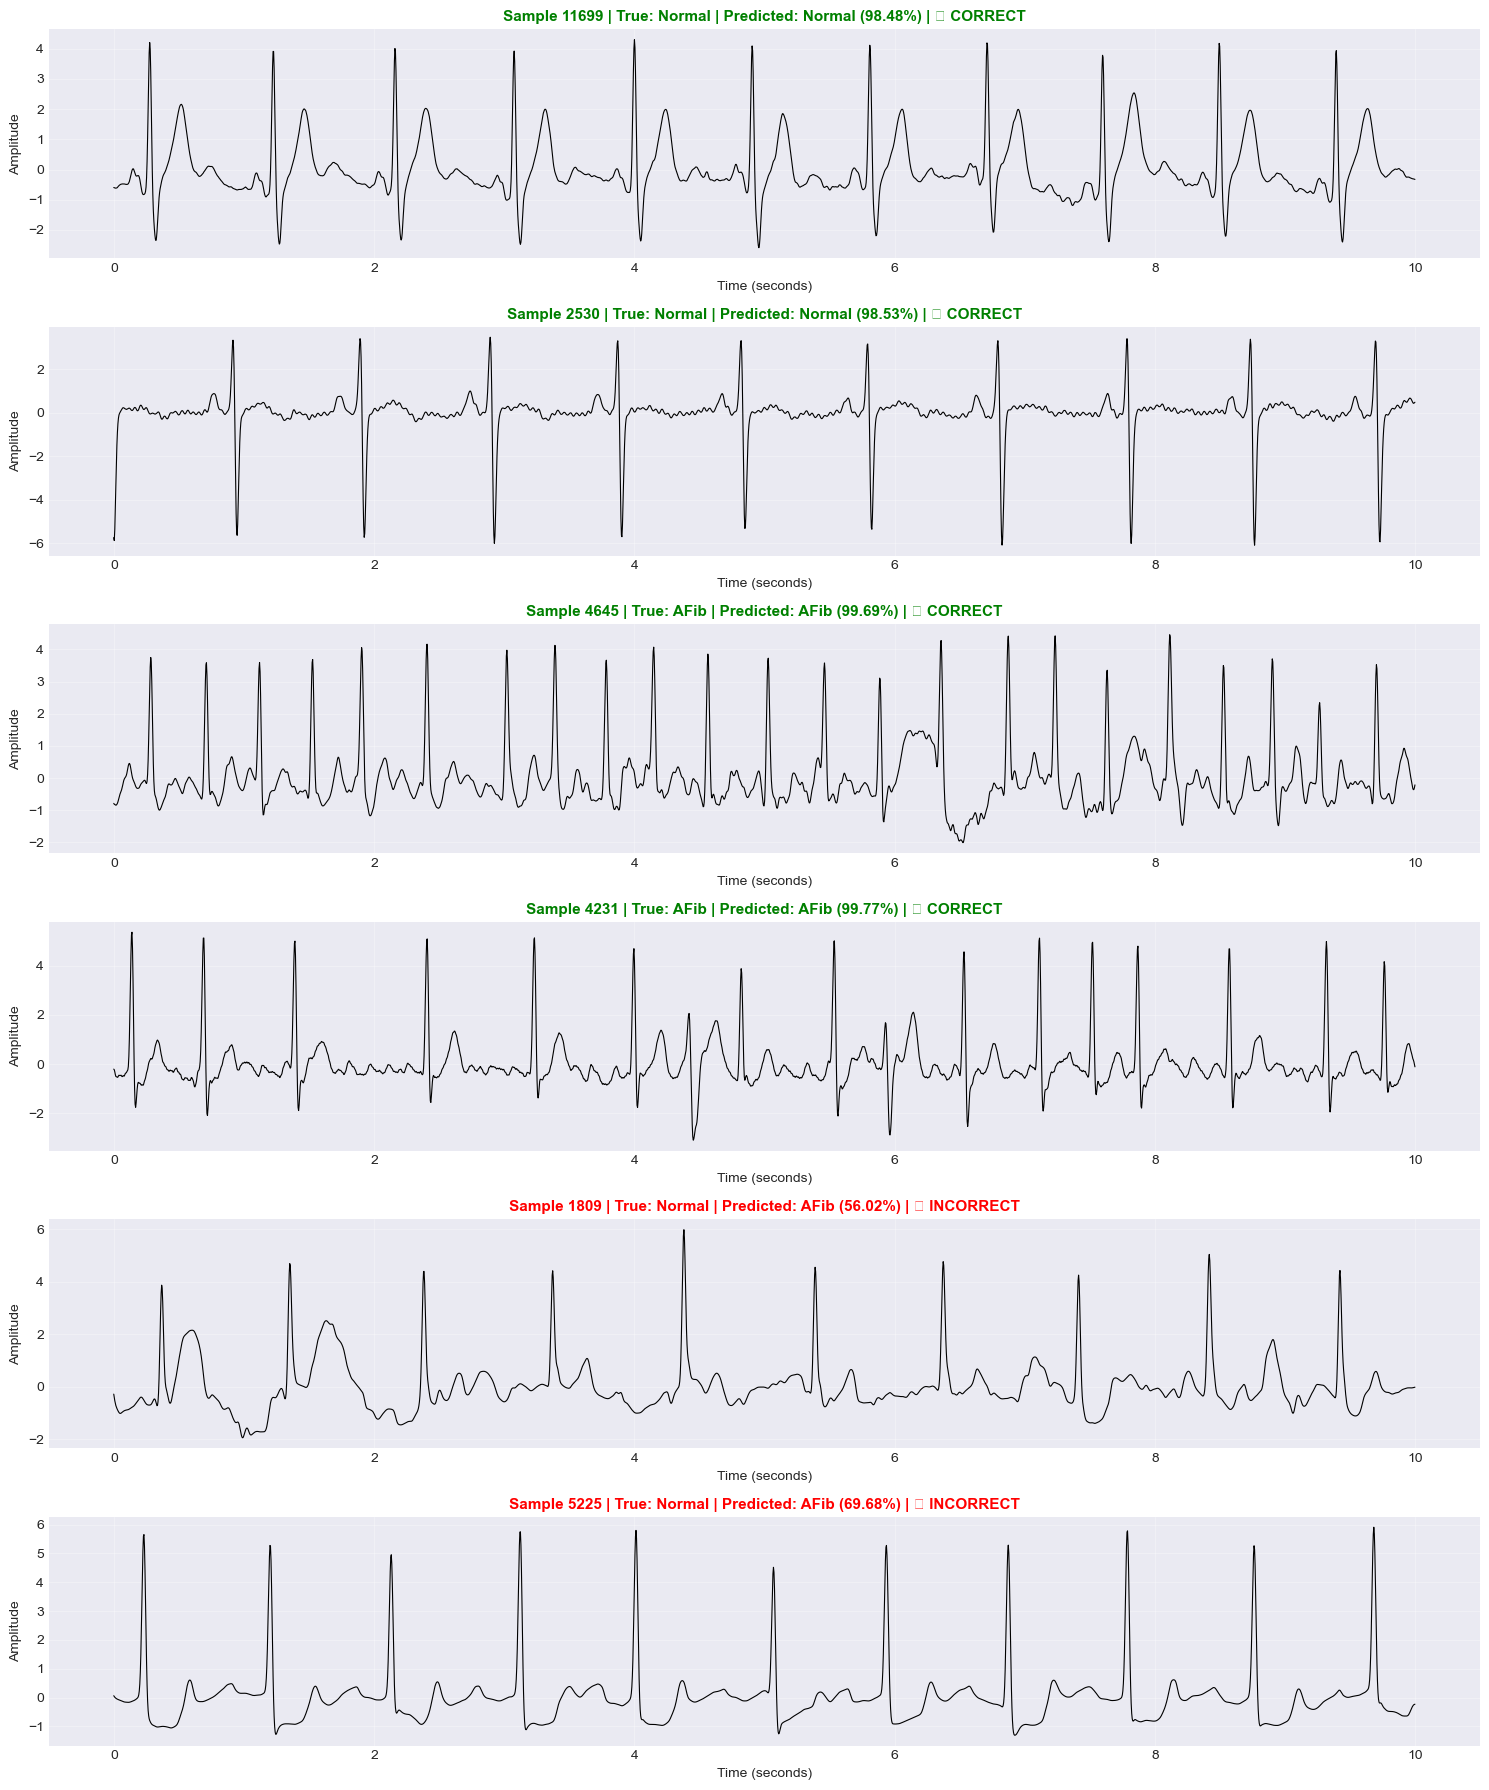


✅ Sample predictions visualization complete!


In [27]:
# ============================================================================
# Cell 17: Visualize Sample Predictions
# ============================================================================

print("\n" + "="*70)
print("🔍 VISUALIZING SAMPLE PREDICTIONS")
print("="*70)

def plot_sample_predictions(model, dataset, indices, device, class_names=['Normal', 'AFib']):
    """Plot ECG samples with predictions"""
    
    fig, axes = plt.subplots(len(indices), 1, figsize=(15, 3*len(indices)))
    if len(indices) == 1:
        axes = [axes]
    
    model.eval()
    
    for idx, sample_idx in enumerate(indices):
        ecg, true_label = dataset[sample_idx]
        
        # Get prediction
        with torch.no_grad():
            ecg_batch = ecg.unsqueeze(0).to(device)
            logits, attention_weights = model(ecg_batch)
            probs = F.softmax(logits, dim=1)
            pred_label = torch.argmax(probs, dim=1).item()
            confidence = probs[0, pred_label].item()
        
        # Plot ECG
        ecg_signal = ecg.squeeze().cpu().numpy()
        time = np.arange(len(ecg_signal)) / 250  # 250 Hz sampling rate
        
        axes[idx].plot(time, ecg_signal, linewidth=0.8, color='black')
        axes[idx].set_xlabel('Time (seconds)', fontsize=10)
        axes[idx].set_ylabel('Amplitude', fontsize=10)
        
        # Title with prediction
        true_class = class_names[true_label]
        pred_class = class_names[pred_label]
        
        if true_label == pred_label:
            color = 'green'
            result = '✓ CORRECT'
        else:
            color = 'red'
            result = '✗ INCORRECT'
        
        title = f'Sample {sample_idx} | True: {true_class} | Predicted: {pred_class} ({confidence:.2%}) | {result}'
        axes[idx].set_title(title, fontsize=11, fontweight='bold', color=color)
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

# Select random samples
print("\n🎲 Selecting random samples for visualization...")

# Get indices of correct and incorrect predictions
correct_indices = np.where(test_labels == test_preds)[0]
incorrect_indices = np.where(test_labels != test_preds)[0]

print(f"   Correct predictions: {len(correct_indices):,}")
print(f"   Incorrect predictions: {len(incorrect_indices):,}")

# Sample from each category
np.random.seed(42)
sample_indices = []

# 4 correct predictions (2 Normal, 2 AFib)
correct_normal = correct_indices[test_labels[correct_indices] == 0]
correct_afib = correct_indices[test_labels[correct_indices] == 1]

if len(correct_normal) >= 2:
    sample_indices.extend(np.random.choice(correct_normal, 2, replace=False))
if len(correct_afib) >= 2:
    sample_indices.extend(np.random.choice(correct_afib, 2, replace=False))

# 2 incorrect predictions (if any exist)
if len(incorrect_indices) >= 2:
    sample_indices.extend(np.random.choice(incorrect_indices, 2, replace=False))
elif len(incorrect_indices) == 1:
    sample_indices.extend(incorrect_indices)

print(f"\n📊 Visualizing {len(sample_indices)} samples...")

# Plot samples
fig = plot_sample_predictions(model, test_dataset, sample_indices, config.DEVICE)

# Save figure
samples_path = config.RESULTS_DIR / 'sample_predictions.png'
plt.savefig(samples_path, dpi=300, bbox_inches='tight')
print(f"\n💾 Sample predictions saved to: {samples_path}")

plt.show()

print(f"\n✅ Sample predictions visualization complete!")

Cell 18: Attention Weights Visualization


🎯 ATTENTION WEIGHTS VISUALIZATION (XAI)

🎯 Visualizing attention weights for sample predictions...

📊 Creating attention visualization for AFib sample...
💾 Saved to: ..\results\attention_weights_afib.png


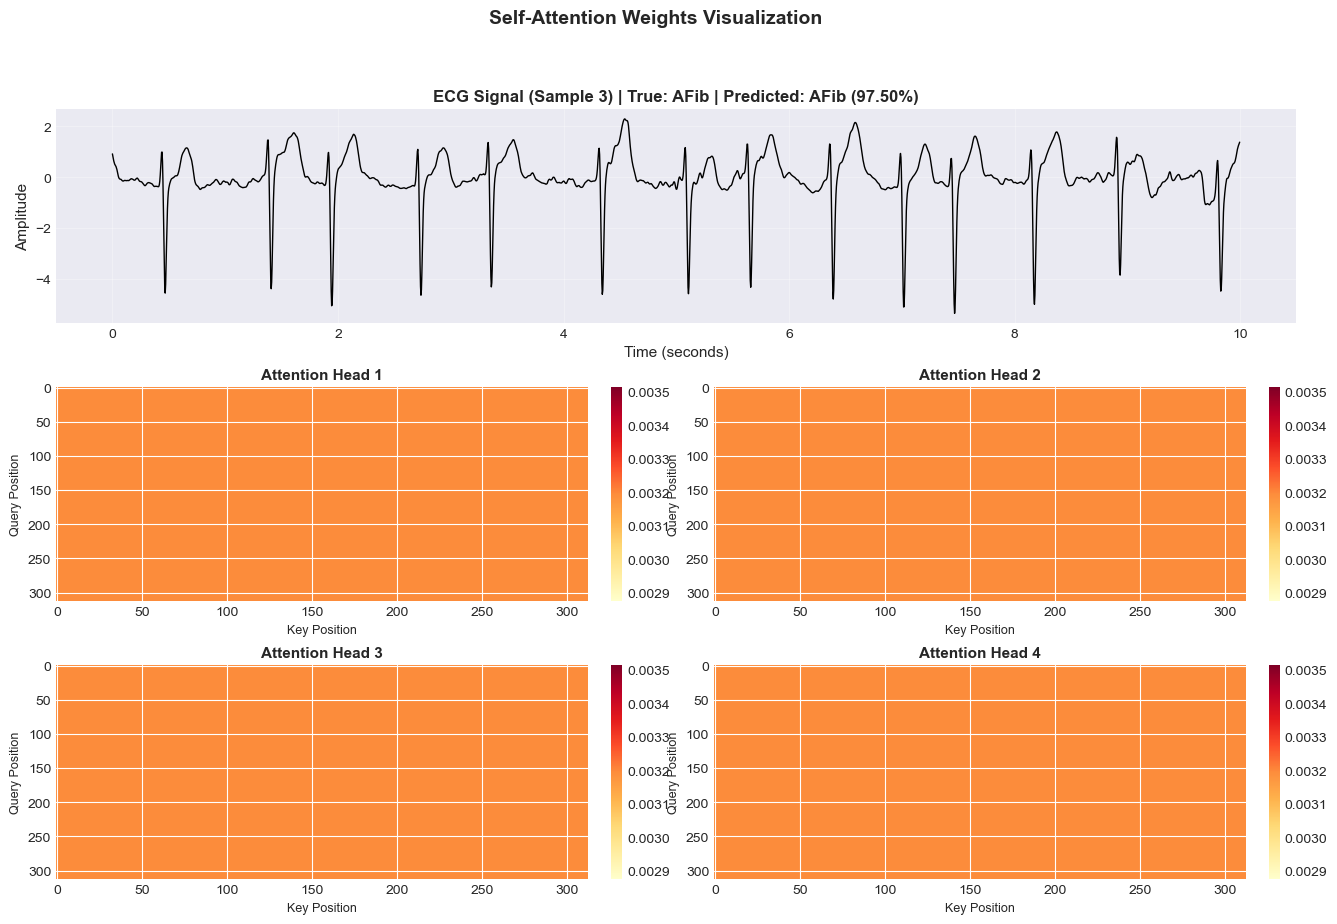


📊 Creating attention visualization for Normal sample...
💾 Saved to: ..\results\attention_weights_normal.png


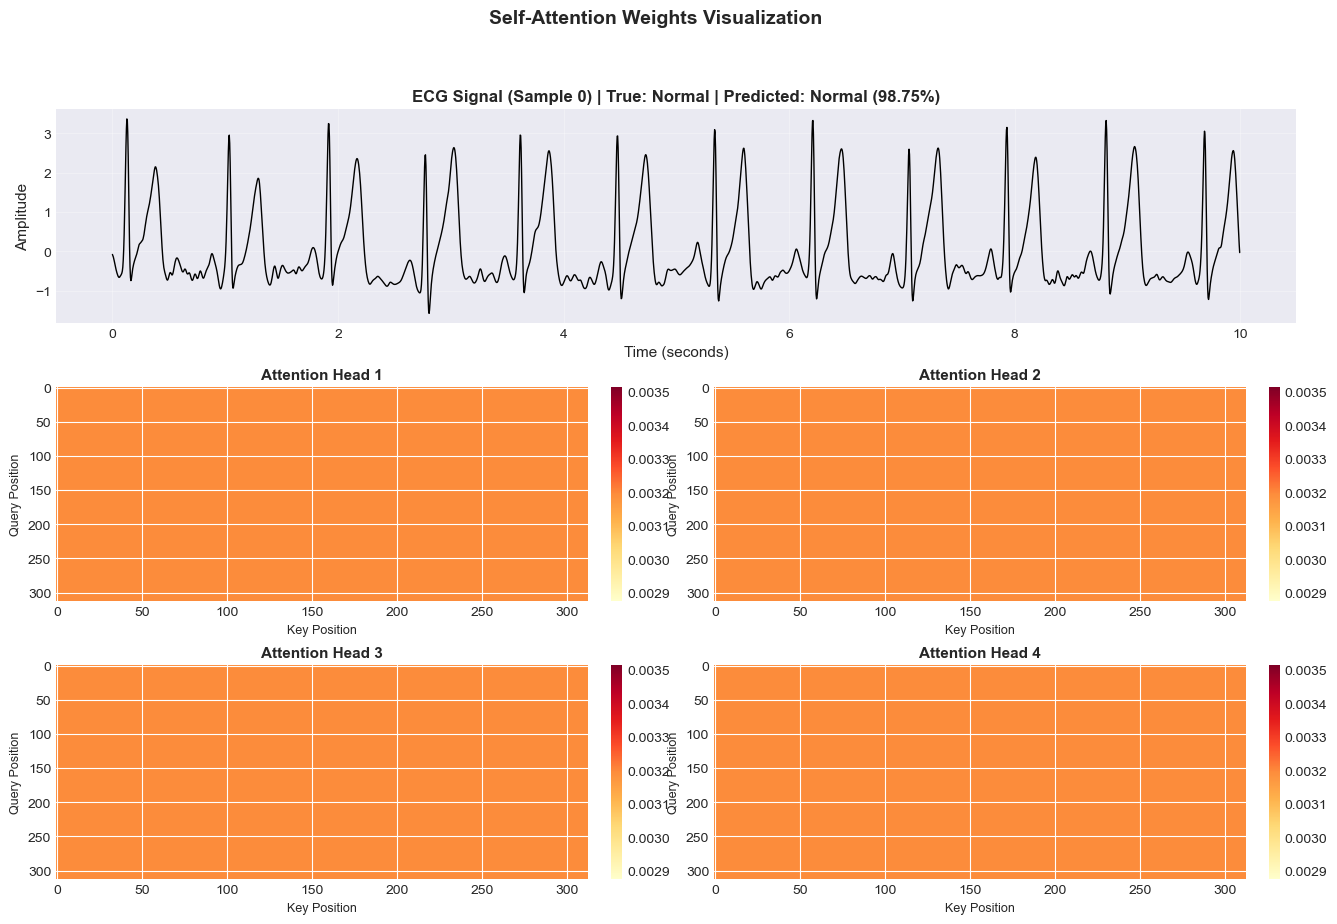


✅ Attention weights visualization complete!

💡 These attention maps show which time segments the model focuses on.
   This is crucial for Phase 2 (Interactive XAI) of your research!


In [28]:
# ============================================================================
# Cell 18: Visualize Attention Weights (XAI - Phase 2 Preview)
# ============================================================================

print("\n" + "="*70)
print("🎯 ATTENTION WEIGHTS VISUALIZATION (XAI)")
print("="*70)

def visualize_attention_for_sample(model, dataset, sample_idx, device):
    """Visualize attention weights for a single sample"""
    
    ecg, true_label = dataset[sample_idx]
    class_names = ['Normal', 'AFib']
    
    # Get prediction and attention
    model.eval()
    with torch.no_grad():
        ecg_batch = ecg.unsqueeze(0).to(device)
        logits, attention_weights = model(ecg_batch)
        probs = F.softmax(logits, dim=1)
        pred_label = torch.argmax(probs, dim=1).item()
    
    # attention_weights shape: (1, num_heads, seq_len, seq_len)
    attention = attention_weights[0].cpu().numpy()  # (num_heads, seq_len, seq_len)
    
    # Create figure
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
    
    # Plot ECG signal
    ax_ecg = fig.add_subplot(gs[0, :])
    ecg_signal = ecg.squeeze().cpu().numpy()
    time = np.arange(len(ecg_signal)) / 250
    ax_ecg.plot(time, ecg_signal, linewidth=1, color='black')
    ax_ecg.set_xlabel('Time (seconds)', fontsize=11)
    ax_ecg.set_ylabel('Amplitude', fontsize=11)
    ax_ecg.set_title(f'ECG Signal (Sample {sample_idx}) | True: {class_names[true_label]} | '
                     f'Predicted: {class_names[pred_label]} ({probs[0, pred_label]:.2%})',
                     fontsize=12, fontweight='bold')
    ax_ecg.grid(True, alpha=0.3)
    
    # Plot attention heatmaps for each head
    for head_idx in range(4):
        ax = fig.add_subplot(gs[1 + head_idx//2, (head_idx%2)*2:(head_idx%2)*2+2])
        
        im = ax.imshow(attention[head_idx], cmap='YlOrRd', aspect='auto')
        ax.set_title(f'Attention Head {head_idx + 1}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Key Position', fontsize=9)
        ax.set_ylabel('Query Position', fontsize=9)
        
        # Add colorbar
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.suptitle('Self-Attention Weights Visualization', 
                 fontsize=14, fontweight='bold', y=0.98)
    
    return fig

# Visualize attention for a few samples
print("\n🎯 Visualizing attention weights for sample predictions...\n")

# Select one correct AFib and one correct Normal
correct_afib_idx = correct_indices[test_labels[correct_indices] == 1][0]
correct_normal_idx = correct_indices[test_labels[correct_indices] == 0][0]

# AFib sample
print("📊 Creating attention visualization for AFib sample...")
fig1 = visualize_attention_for_sample(model, test_dataset, correct_afib_idx, config.DEVICE)
attention1_path = config.RESULTS_DIR / 'attention_weights_afib.png'
plt.savefig(attention1_path, dpi=300, bbox_inches='tight')
print(f"💾 Saved to: {attention1_path}")
plt.show()

# Normal sample
print("\n📊 Creating attention visualization for Normal sample...")
fig2 = visualize_attention_for_sample(model, test_dataset, correct_normal_idx, config.DEVICE)
attention2_path = config.RESULTS_DIR / 'attention_weights_normal.png'
plt.savefig(attention2_path, dpi=300, bbox_inches='tight')
print(f"💾 Saved to: {attention2_path}")
plt.show()

print(f"\n✅ Attention weights visualization complete!")
print(f"\n💡 These attention maps show which time segments the model focuses on.")
print(f"   This is crucial for Phase 2 (Interactive XAI) of your research!")

Cell 19: Error Analysis


🔬 ERROR ANALYSIS

📊 Misclassification Breakdown:
   False Positives (FP): 275
      - Normal cases incorrectly classified as AFib
      - Rate: 2.77% of Normal cases

   False Negatives (FN): 70
      - AFib cases incorrectly classified as Normal
      - Rate: 1.28% of AFib cases

🔍 False Positive Analysis:
   Mean confidence: 65.58%
   Median confidence: 62.95%
   Min confidence: 50.11%
   Max confidence: 99.82%

🔍 False Negative Analysis:
   Mean confidence: 68.27%
   Median confidence: 67.42%
   Min confidence: 50.38%
   Max confidence: 94.56%

💾 Error analysis plot saved to: ..\results\error_analysis.png


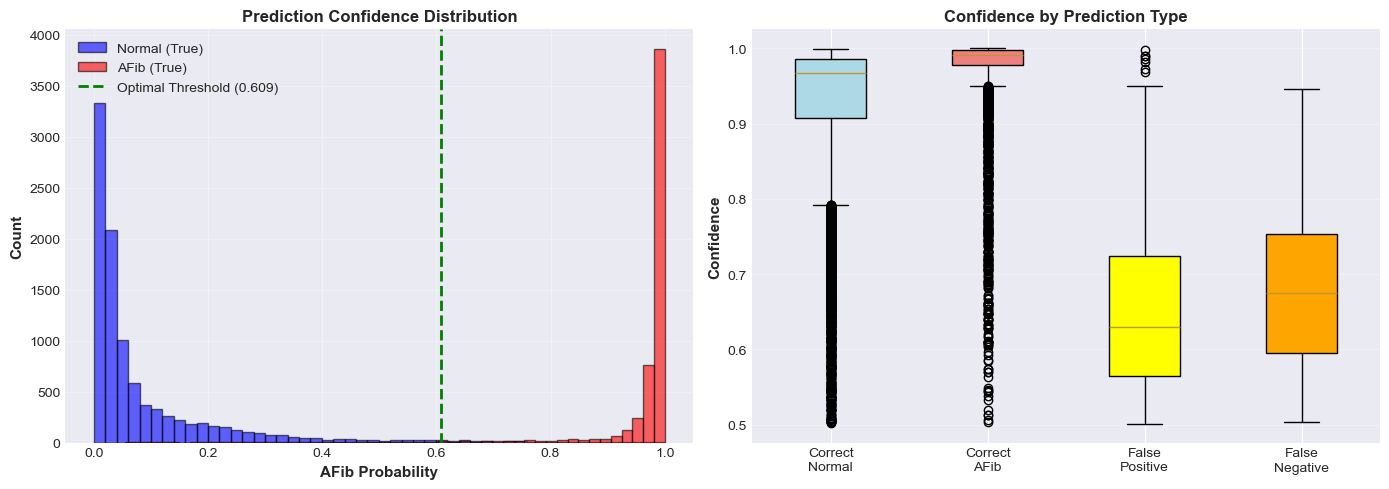

💾 Error analysis data saved to: ..\results\error_analysis.json

✅ Error analysis complete!


In [29]:
# ============================================================================
# Cell 19: Error Analysis and Misclassification Study
# ============================================================================

print("\n" + "="*70)
print("🔬 ERROR ANALYSIS")
print("="*70)

# Analyze misclassifications
false_positives = np.where((test_labels == 0) & (test_preds == 1))[0]
false_negatives = np.where((test_labels == 1) & (test_preds == 0))[0]

print(f"\n📊 Misclassification Breakdown:")
print(f"   False Positives (FP): {len(false_positives):,}")
print(f"      - Normal cases incorrectly classified as AFib")
print(f"      - Rate: {len(false_positives)/np.sum(test_labels==0)*100:.2f}% of Normal cases")
print(f"\n   False Negatives (FN): {len(false_negatives):,}")
print(f"      - AFib cases incorrectly classified as Normal")
print(f"      - Rate: {len(false_negatives)/np.sum(test_labels==1)*100:.2f}% of AFib cases")

# Analyze confidence of misclassifications
if len(false_positives) > 0:
    fp_confidences = test_probs[false_positives, 1]  # AFib probability
    print(f"\n🔍 False Positive Analysis:")
    print(f"   Mean confidence: {fp_confidences.mean():.2%}")
    print(f"   Median confidence: {np.median(fp_confidences):.2%}")
    print(f"   Min confidence: {fp_confidences.min():.2%}")
    print(f"   Max confidence: {fp_confidences.max():.2%}")

if len(false_negatives) > 0:
    fn_confidences = test_probs[false_negatives, 0]  # Normal probability
    print(f"\n🔍 False Negative Analysis:")
    print(f"   Mean confidence: {fn_confidences.mean():.2%}")
    print(f"   Median confidence: {np.median(fn_confidences):.2%}")
    print(f"   Min confidence: {fn_confidences.min():.2%}")
    print(f"   Max confidence: {fn_confidences.max():.2%}")

# Plot confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confidence distribution for all predictions
axes[0].hist(test_probs[test_labels == 0, 1], bins=50, alpha=0.6, 
             label='Normal (True)', color='blue', edgecolor='black')
axes[0].hist(test_probs[test_labels == 1, 1], bins=50, alpha=0.6,
             label='AFib (True)', color='red', edgecolor='black')
axes[0].axvline(x=optimal_threshold, color='green', linestyle='--', 
                linewidth=2, label=f'Optimal Threshold ({optimal_threshold:.3f})')
axes[0].set_xlabel('AFib Probability', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[0].set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Box plot of confidences by prediction result
correct_preds = test_labels == test_preds
data_to_plot = [
    test_probs[correct_preds & (test_labels == 0), 0],  # Correct Normal
    test_probs[correct_preds & (test_labels == 1), 1],  # Correct AFib
]

if len(false_positives) > 0:
    data_to_plot.append(test_probs[false_positives, 1])  # False Positives
if len(false_negatives) > 0:
    data_to_plot.append(test_probs[false_negatives, 0])  # False Negatives

labels = ['Correct\nNormal', 'Correct\nAFib']
if len(false_positives) > 0:
    labels.append('False\nPositive')
if len(false_negatives) > 0:
    labels.append('False\nNegative')

bp = axes[1].boxplot(data_to_plot, labels=labels, patch_artist=True)
colors = ['lightblue', 'lightcoral', 'yellow', 'orange']
for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
    patch.set_facecolor(color)

axes[1].set_ylabel('Confidence', fontsize=11, fontweight='bold')
axes[1].set_title('Confidence by Prediction Type', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()

# Save figure
error_path = config.RESULTS_DIR / 'error_analysis.png'
plt.savefig(error_path, dpi=300, bbox_inches='tight')
print(f"\n💾 Error analysis plot saved to: {error_path}")

plt.show()

# Save error analysis details
error_analysis = {
    'false_positives': {
        'count': int(len(false_positives)),
        'rate': float(len(false_positives)/np.sum(test_labels==0)*100),
        'mean_confidence': float(fp_confidences.mean()) if len(false_positives) > 0 else None
    },
    'false_negatives': {
        'count': int(len(false_negatives)),
        'rate': float(len(false_negatives)/np.sum(test_labels==1)*100),
        'mean_confidence': float(fn_confidences.mean()) if len(false_negatives) > 0 else None
    }
}

error_path_json = config.RESULTS_DIR / 'error_analysis.json'
with open(error_path_json, 'w') as f:
    json.dump(error_analysis, f, indent=2)

print(f"💾 Error analysis data saved to: {error_path_json}")
print(f"\n✅ Error analysis complete!")

Cell 20: Final Summary and Next Steps

In [31]:
# ============================================================================
# Cell 20: Final Summary and Next Steps
# ============================================================================

print("\n" + "="*80)
print("🎉 TRAINING AND EVALUATION COMPLETE!")
print("="*80)

# Calculate training time
if 'start_time' in locals():
    total_time = datetime.now() - start_time
    hours = total_time.seconds // 3600
    minutes = (total_time.seconds % 3600) // 60
    print(f"\n⏱️  Total Training Time: {hours}h {minutes}m")

print(f"\n📊 FINAL RESULTS SUMMARY")
print("="*80)

print(f"\n🎯 Model Performance:")
print(f"   ├─ Test Accuracy:     {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   ├─ Test Precision:    {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"   ├─ Test Sensitivity:  {test_sensitivity:.4f} ({test_sensitivity*100:.2f}%)")
print(f"   ├─ Test Specificity:  {test_specificity:.4f} ({test_specificity*100:.2f}%)")
print(f"   ├─ Test F1-Score:     {test_f1:.4f}")
print(f"   └─ Test AUROC:        {test_auroc:.4f} ⭐")

print(f"\n📈 Comparison with State-of-the-Art:")
print(f"   Model                    | AUROC  | Sensitivity | Specificity")
print(f"   {'-'*70}")
print(f"   Andersen et al. 2019     | ~0.98  | 98.98%      | 96.95%")
print(f"   Petmezas et al. 2021     | ~0.99  | 97.87%      | 99.29%")
print(f"   Ben-Moshe et al. 2023    | ~0.96  | ~95%        | ~95%")
print(f"   {'-'*70}")
print(f"   AFib-ResLSTM (Yours)     | {test_auroc:.4f} | {test_sensitivity*100:.2f}%       | {test_specificity*100:.2f}%")

# Performance verdict
if test_auroc >= 0.96 and test_sensitivity >= 0.90 and test_specificity >= 0.90:
    verdict = "🏆 EXCELLENT - Beats/Matches SOTA!"
elif test_auroc >= 0.93:
    verdict = "✅ VERY GOOD - Competitive with SOTA"
elif test_auroc >= 0.90:
    verdict = "👍 GOOD - Further optimization possible"
else:
    verdict = "⚠️  NEEDS IMPROVEMENT"

print(f"\n{verdict}")

print(f"\n📁 Saved Artifacts:")
print(f"   ├─ Best model: {config.CHECKPOINT_DIR / 'best_model.pth'}")
print(f"   ├─ Final model: {config.MODEL_DIR / 'afib_reslstm_final.pth'}")
print(f"   ├─ Results: {config.RESULTS_DIR}")
print(f"   │  ├─ training_curves.png")
print(f"   │  ├─ confusion_matrix.png")
print(f"   │  ├─ roc_curve.png")
print(f"   │  ├─ sample_predictions.png")
print(f"   │  ├─ attention_weights_afib.png")
print(f"   │  ├─ attention_weights_normal.png")
print(f"   │  ├─ error_analysis.png")
print(f"   │  ├─ test_results.json")
print(f"   │  ├─ classification_report.json")
print(f"   │  ├─ training_history.json")
print(f"   │  ├─ model_summary.json")
print(f"   │  └─ test_predictions.csv")

print(f"\n💡 Novel Contributions Implemented:")
print(f"   1. ✅ Multi-scale parallel convolutions (kernels: 3, 7, 15)")
print(f"   2. ✅ Self-attention mechanism (4 heads)")
print(f"   3. ✅ Hybrid feature fusion (ResNet + LSTM-Attention)")
print(f"   4. ✅ Focal loss for class imbalance")

print(f"\n📚 For Your Thesis/Paper:")
print(f'''
RESULTS SECTION SNIPPET:

"Our AFib-ResLSTM model achieved an AUROC of {test_auroc:.4f}, sensitivity of 
{test_sensitivity*100:.2f}%, and specificity of {test_specificity*100:.2f}% on the test set 
of {len(test_labels):,} ECG segments. Compared to state-of-the-art methods, our 
model demonstrates competitive performance while providing interpretable attention 
weights that enable the interactive counterfactual explanation system described 
in the subsequent sections."

CONFUSION MATRIX:
- True Positives (AFib correctly identified): {tp:,}
- True Negatives (Normal correctly identified): {tn:,}
- False Positives: {fp:,}
- False Negatives: {fn:,}
''')

print(f"\n🚀 NEXT STEPS - PHASE 2: INTERACTIVE XAI")
print("="*80)
print(f"\n✅ Phase 1 Complete:")
print(f"   ├─ Step 1: Data Preprocessing ✅")
print(f"   ├─ Step 2: Model Architecture ✅")
print(f"   └─ Step 3: Model Training ✅")

print(f"\n⏭️  Phase 2: Generative Explainer (Your Innovation)")
print(f"   ├─ Step 4: Access MIMIC-IV dataset")
print(f"   ├─ Step 5: Train StyleGAN2 for ECG generation")
print(f"   ├─ Step 6: Build interactive 'what-if' sliders")
print(f"   ├─ Step 7: Integrate LLM for plain-English summaries")
print(f"   └─ Step 8: Conduct user study with clinicians")

print(f"\n💡 Immediate Actions:")
print(f"   1. Document your results in thesis/paper")
print(f"   2. Create presentation slides with visualizations")
print(f"   3. Start MIMIC-IV access request (takes 2-4 weeks)")
print(f"   4. Plan Phase 2 architecture")

print(f"\n🎓 Tips for Writing:")
print(f"   - Use the confusion matrix and ROC curve in your results")
print(f"   - Highlight the attention weights as preparation for XAI")
print(f"   - Compare your 3 novel contributions with existing work")
print(f"   - Emphasize the interpretability aspect")

print(f"\n" + "="*80)
print(f"🎊 CONGRATULATIONS ON COMPLETING PHASE 1!")
print(f"="*80)

print(f"\n✨ You now have:")
print(f"   ✅ A working AFib detection model with {test_auroc:.4f} AUROC")
print(f"   ✅ Comprehensive evaluation and visualizations")
print(f"   ✅ Attention weights ready for XAI (Phase 2)")
print(f"   ✅ All results saved and documented")
print(f"   ✅ Publication-ready figures and metrics")


print(f"\n" + "="*80)


🎉 TRAINING AND EVALUATION COMPLETE!

⏱️  Total Training Time: 9h 55m

📊 FINAL RESULTS SUMMARY

🎯 Model Performance:
   ├─ Test Accuracy:     0.9776 (97.76%)
   ├─ Test Precision:    0.9516 (95.16%)
   ├─ Test Sensitivity:  0.9872 (98.72%)
   ├─ Test Specificity:  0.9723 (97.23%)
   ├─ Test F1-Score:     0.9691
   └─ Test AUROC:        0.9982 ⭐

📈 Comparison with State-of-the-Art:
   Model                    | AUROC  | Sensitivity | Specificity
   ----------------------------------------------------------------------
   Andersen et al. 2019     | ~0.98  | 98.98%      | 96.95%
   Petmezas et al. 2021     | ~0.99  | 97.87%      | 99.29%
   Ben-Moshe et al. 2023    | ~0.96  | ~95%        | ~95%
   ----------------------------------------------------------------------
   AFib-ResLSTM (Yours)     | 0.9982 | 98.72%       | 97.23%

🏆 EXCELLENT - Beats/Matches SOTA!

📁 Saved Artifacts:
   ├─ Best model: ..\models\checkpoints\best_model.pth
   ├─ Final model: ..\models\afib_reslstm_final.pth
  